# Main script

## Part (i): loading data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
# load .mat data
import scipy.io
from scipy.linalg import pinvh

import xarray as xr
# add ../ to the path
import sys
sys.path.append('../')

import src.model as model

%load_ext autoreload
%autoreload 2

data_path       = os.getenv('DATA_PATH')
param_path      = os.getenv('PARAM_PATH')
split_data_path = "../data/train-validate-test/" # split data set
folder = data_path
# ------------------------------------------------- LOAD SIMULATION DATA -------------------------------------------------
# get the DATA_PATH from the environment variable
XY_train_filename    = "train_data.npz"
XY_valid_filename    = "validation_data.npz"
XY_test_filename     = "test_data.npz"
H_filename           = 'H_gridded.mat'
Y_obs_filename       = "Ns_obs_gridded.mat"
mask_filename        = 'training_mask.mat' 
model_bound_filename = 'training_mask_domain_continuous.mat'
# also the mean and std of Eb for reverse standardization
Eb_mean_filename     = 'trainingAll_Eb_sim_mean.mat'
Eb_std_filename      = 'trainingAll_Eb_sim_std.mat'
# also the mean and std of Ns for standardization of observed data
Ns_mean_filename     = 'trainingAll_Ns_sim_mean_masked.mat'
Ns_std_filename      = 'trainingAll_Ns_sim_std_masked.mat'
# others
coord_filename       = "trainingAll_image_coord.mat"

# preprocessing parameter file: read the csv file
preprocess_param = pd.read_csv(param_path, index_col=0)
Eb_standardize_epsilon = preprocess_param['Eb_standardization_epsilon'].values[0]
Ns_standardize_epsilon = preprocess_param['Ns_standardization_epsilon'].values[0]
print("Eb_standardize_epsilon:", Eb_standardize_epsilon)
print("Ns_standardize_epsilon:", Ns_standardize_epsilon)


flight_mask_data = scipy.io.loadmat(folder + mask_filename) # this is the flightline mask
H_data           = scipy.io.loadmat(folder + H_filename)
model_bound_data = scipy.io.loadmat(folder + model_bound_filename) # this is model domain mask
coord_data       = scipy.io.loadmat(folder + coord_filename)
# standardization data for Eb
Eb_mean          = scipy.io.loadmat(folder + Eb_mean_filename)
Eb_std           = scipy.io.loadmat(folder + Eb_std_filename)

# load
Eb_standardized_train = np.load(split_data_path + XY_train_filename)['Eb_train']
Ns_standardized_train = np.load(split_data_path + XY_train_filename)['Ns_train']
Eb_standardized_valid = np.load(split_data_path + XY_valid_filename)['Eb_validation']
Ns_standardized_valid = np.load(split_data_path + XY_valid_filename)['Ns_validation']
Eb_standardized_test  = np.load(split_data_path + XY_test_filename)['Eb_test']
Ns_standardized_test  = np.load(split_data_path + XY_test_filename)['Ns_test']
# replace nan by 0
Eb_mean = np.nan_to_num(Eb_mean['Eb_mean'], nan=0.0).flatten()
Eb_std  = np.nan_to_num(Eb_std['Eb_std'], nan=0.0).flatten()

# load model boundary
model_bound_data_ori = model_bound_data['in_domain_mask'].astype(bool)

x_coord = coord_data['training_coord'][0][0][0]
y_coord = coord_data['training_coord'][0][0][1]
extent = np.array([x_coord.min(), x_coord.max(), y_coord.max(), y_coord.min()])/1e3 # convert to km (left, right, bottom, top), imshow by default is inverted in y-axis

# -------------------------------------------------- LOAD OBSERVATION DATA --------------------------------------------------
Y_obs_data   = scipy.io.loadmat(folder + Y_obs_filename)
# standardization data for Ns
Ns_mean_data = scipy.io.loadmat(folder + Ns_mean_filename)
Ns_std_data  = scipy.io.loadmat(folder + Ns_std_filename)
Ns_mean = Ns_mean_data['Ns_mean_masked']
Ns_std = Ns_std_data['Ns_std_masked']  

Y_obs_data     = Y_obs_data['atten_rate_grid']
atten_rate_avg = Y_obs_data['atten_avg'][0][0]

# apply flightline masking to the standardization mean and std
flight_mask = flight_mask_data['mask']
flight_mask_bool = flight_mask.astype(bool)
Ns_mean_masked = Ns_mean.copy()
Ns_mean_masked[~flight_mask_bool] = 0 # set the mean to 0
Ns_std_masked = Ns_std.copy()
Ns_std_masked[~flight_mask_bool] = 1 # set the std to 1

Ns_mean_masked = Ns_mean_masked.flatten()   
Ns_std_masked  = Ns_std_masked.flatten()

print('Shape of Eb_standardized_train:', Eb_standardized_train.shape)
print('Shape of Ns_standardized_train:', Ns_standardized_train.shape)
print('Shape of domain mask:', model_bound_data_ori.shape)
print('Shape of flight mask:', flight_mask_bool.shape)


Eb_standardize_epsilon: 1287.4819202075
Ns_standardize_epsilon: 0.262291780650704
Shape of Eb_standardized_train: (256, 256, 1, 833)
Shape of Ns_standardized_train: (256, 256, 1, 833)
Shape of domain mask: (256, 256)
Shape of flight mask: (256, 256)


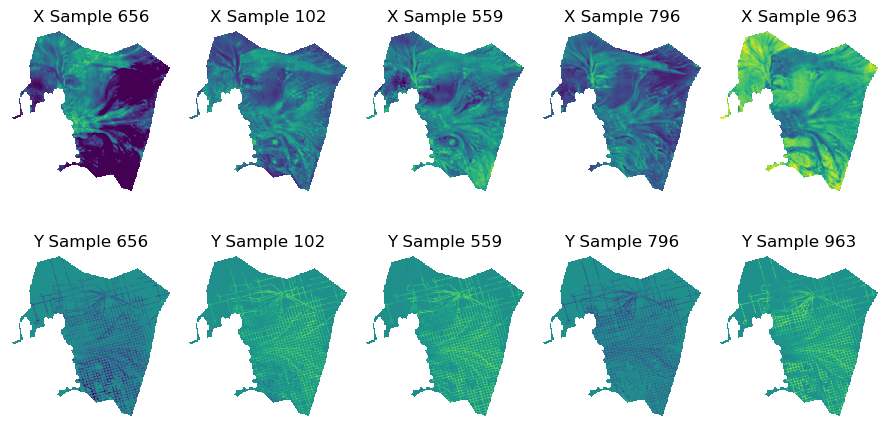

In [2]:
# initialize the model object
md = model.model(extent=extent, coord=(x_coord, y_coord))

# load training data
# first combine all so that our PCA is operated on the whole dataset
Eb_standardized_all = np.concatenate([Eb_standardized_train, 
                                      Eb_standardized_valid, 
                                      Eb_standardized_test], 
                                      axis=3)
Ns_standardized_all = np.concatenate([Ns_standardized_train, 
                                      Ns_standardized_valid, 
                                      Ns_standardized_test], 
                                      axis=3)
md.load_sim_data(Eb_standardized_all, Ns_standardized_all, 
                 domain_mask=model_bound_data_ori, 
                 flight_mask=flight_mask_bool, 
                 show_plot=True)

md.load_standardization_data(X_mean=Eb_mean, X_std=Eb_std,
                             Y_mean=Ns_mean_masked, Y_std=Ns_std_masked,
                             X_epsilon=Eb_standardize_epsilon, Y_epsilon=Ns_standardize_epsilon)

## Part (ii): inspecting data dimension with PCA

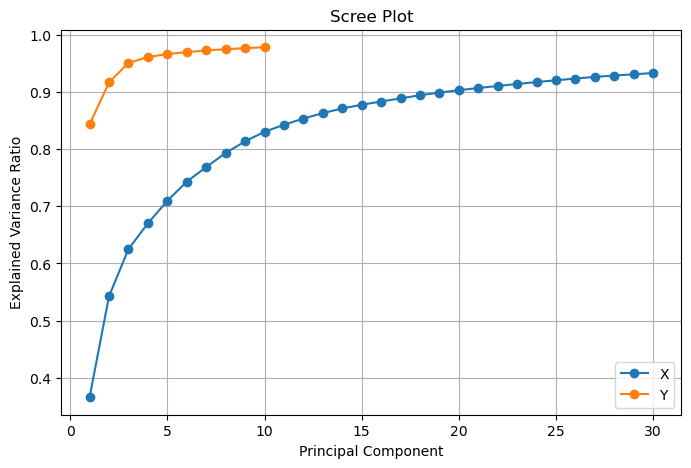

In [147]:
md.pca_scree(n_component_x=30, n_component_y=10)

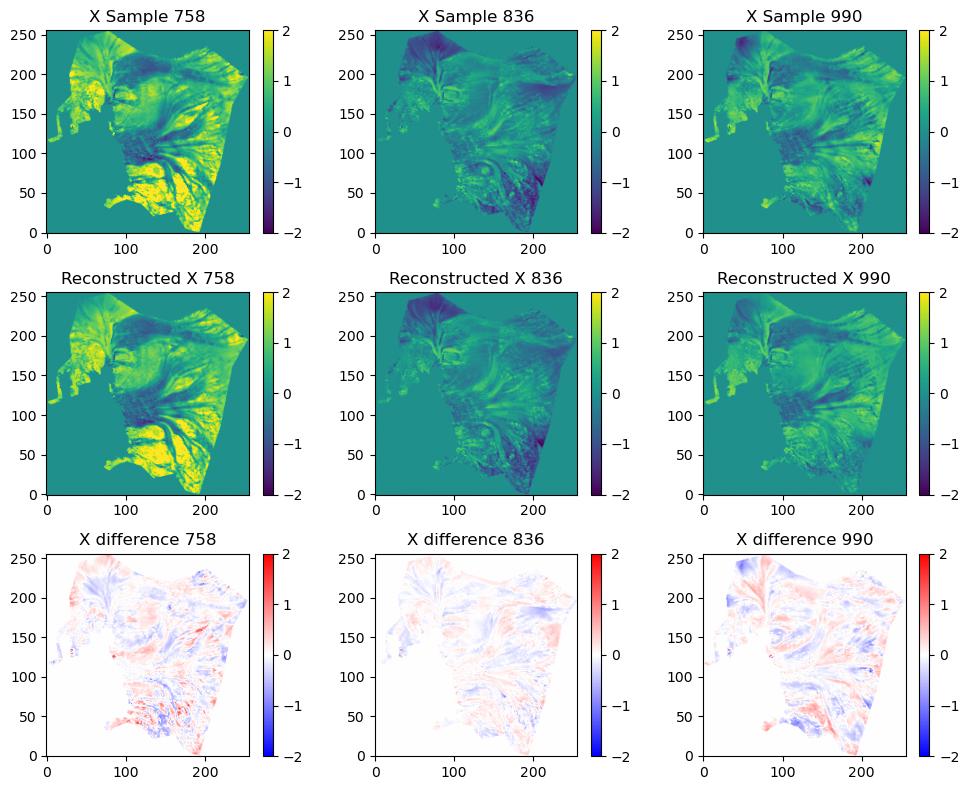

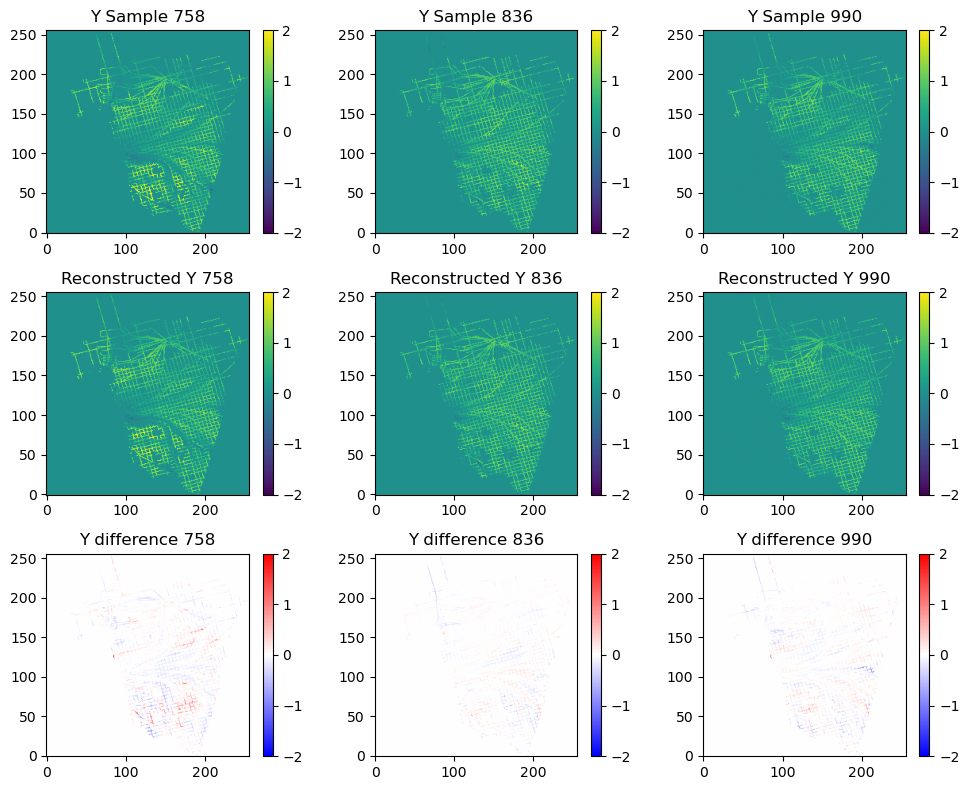

In [165]:
md.pca_recon_inspection(n_component_x=30, n_component_y=10)

## Part (iii): Dimension reduction and derive the informative prior

PCA model saved to self.pca_x and self.pca_y.
Shape of XY_train: (833, 33)
Shape of XY_validation: (104, 33)
Shape of XY_test: (105, 33)
GMM training completed in 0.00 seconds.
k*ln(n): 3994.6699834471046  - 2*L: 210367.78089419252 BIC: 214362.4508776396
n_components: 1 BIC: 214362.4508776396
GMM training completed in 0.01 seconds.
k*ln(n): 7996.065000536377  - 2*L: 194364.31260538794 BIC: 202360.37760592432
n_components: 2 BIC: 202360.37760592432
GMM training completed in 0.08 seconds.
k*ln(n): 11997.460017625648  - 2*L: 189360.40621105328 BIC: 201357.86622867893
n_components: 3 BIC: 201357.86622867893
GMM training completed in 0.10 seconds.
k*ln(n): 15998.85503471492  - 2*L: 185239.9599422055 BIC: 201238.8149769204
n_components: 4 BIC: 201238.8149769204
GMM training completed in 0.05 seconds.
k*ln(n): 20000.250051804192  - 2*L: 186563.27151751384 BIC: 206563.52156931802
n_components: 5 BIC: 206563.52156931802
GMM training completed in 0.25 seconds.
k*ln(n): 24001.645068893464  - 2*L:

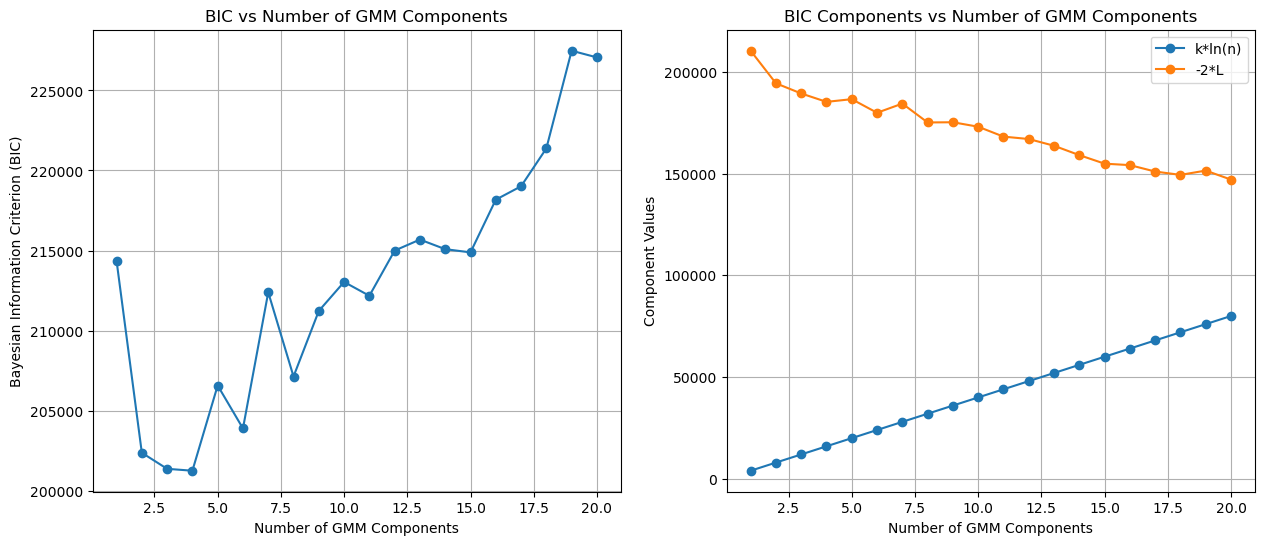

GMM training completed in 0.05 seconds.


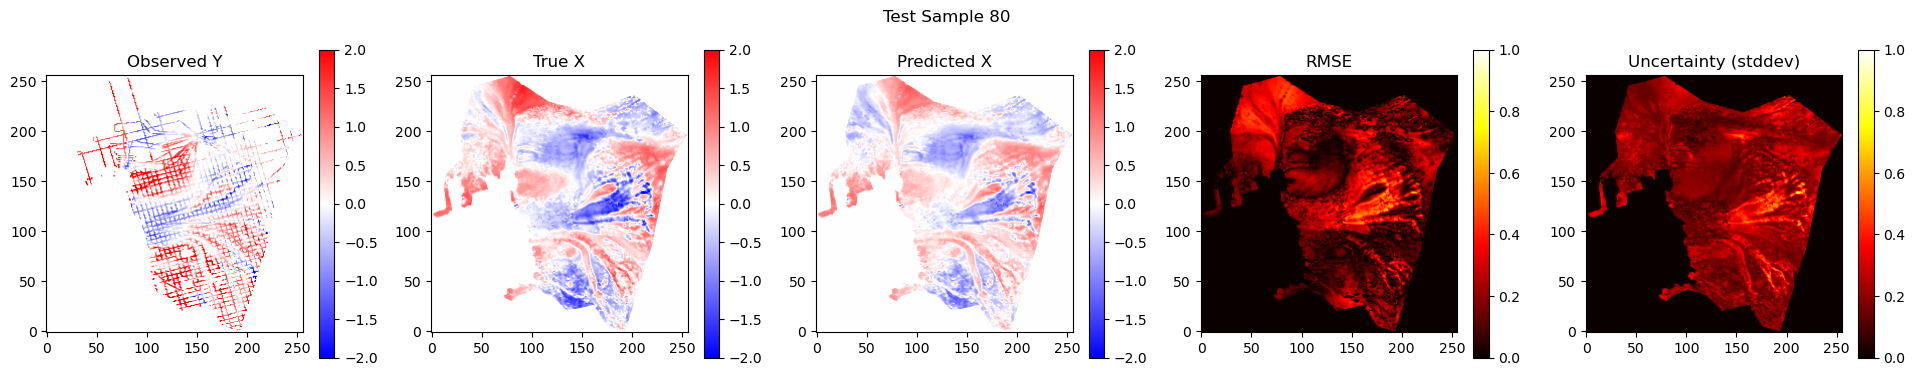

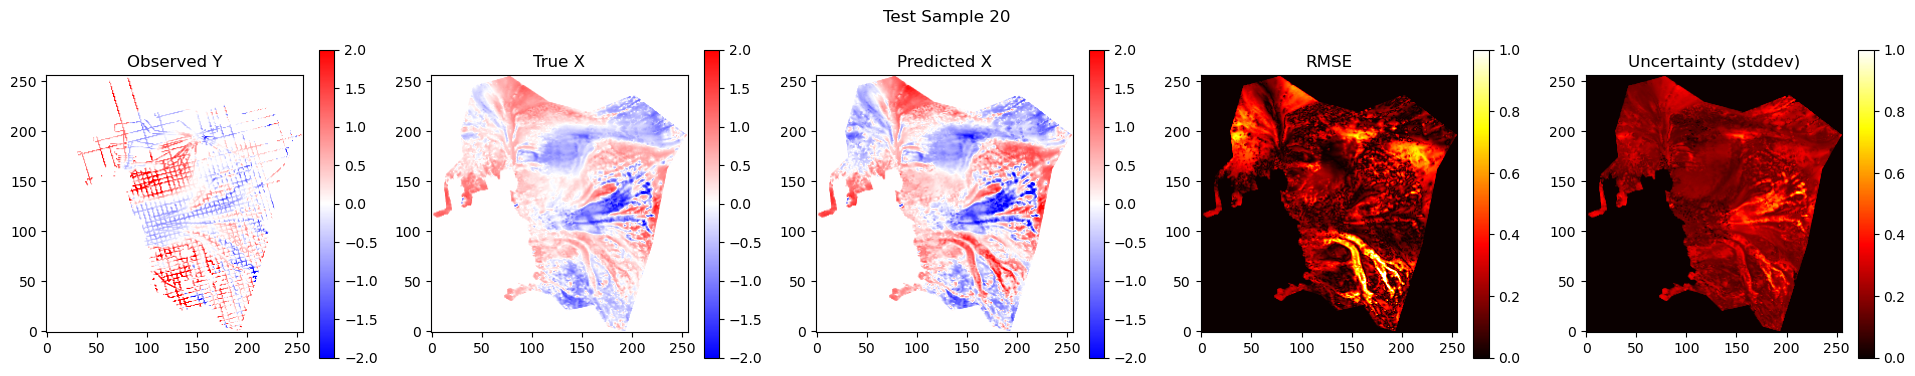

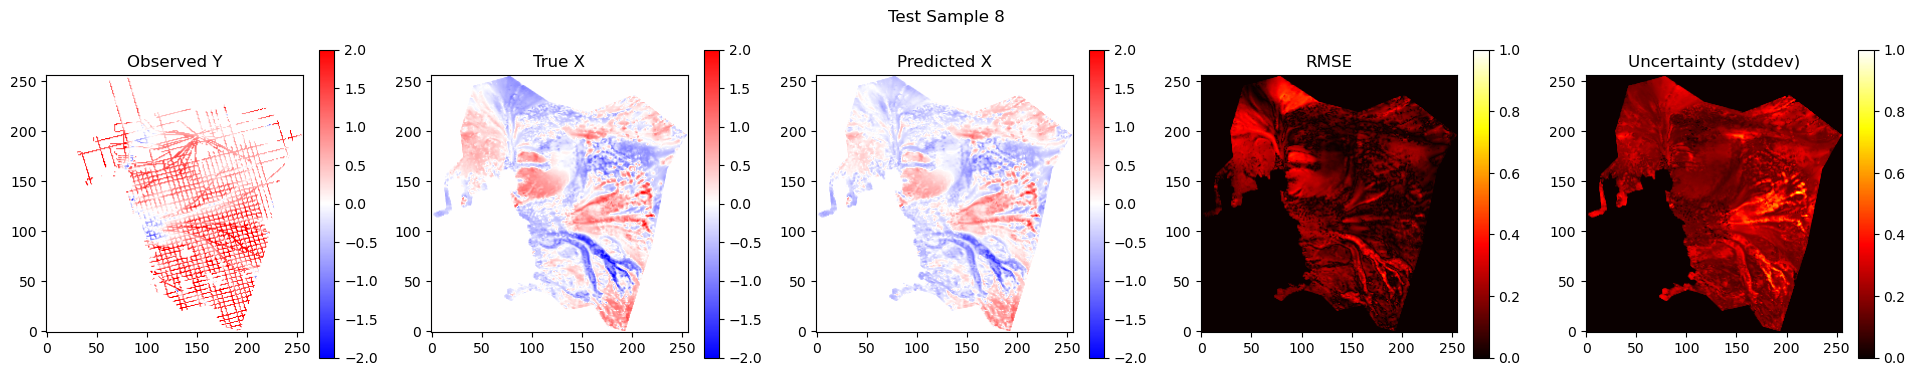

In [3]:
from src.validation import bayesian_information_criterion

# reduce dim with PCA. 
md.find_reduction_model_pca(n_component_x=25, n_component_y=8)

# load specifically the train, validation, and test (pre-split) data and apply the fitted PCA
md.load_split_data(X_train=Eb_standardized_train, Y_train=Ns_standardized_train,
                   X_validation=Eb_standardized_valid, Y_validation=Ns_standardized_valid,
                   X_test=Eb_standardized_test, Y_test=Ns_standardized_test)

y_train = md.XY_train[:, md.y_indices]
x_train = md.XY_train[:, md.x_indices]

# Run Bayesian Information Criterion (BIC) sweep to find the optimal number of GMM components
gmm_components = np.linspace(1, 20, 20, dtype=int)
bic_list = []
kln_list = []
neg2L_list = []
for n_components in gmm_components:
    md.train_gmm_XY(n_components=n_components)
    bic, kln, neg2L = bayesian_information_criterion(md, x_train, y_train, n = md.n_samples_train)
    bic_list.append(bic)
    kln_list.append(kln)
    neg2L_list.append(neg2L)
    print("n_components:", n_components, "BIC:", bic)

plt.figure(figsize=(15, 6))
plt.subplot(1,2,1)
plt.plot(gmm_components, bic_list, marker='o')
plt.xlabel('Number of GMM Components')
plt.ylabel('Bayesian Information Criterion (BIC)')
plt.title('BIC vs Number of GMM Components')
plt.grid()
# plot the component
plt.subplot(1,2,2)
plt.plot(gmm_components, kln_list, marker='o', label='k*ln(n)')
plt.plot(gmm_components, neg2L_list, marker='o', label='-2*L')
plt.xlabel('Number of GMM Components')
plt.ylabel('Component Values')
plt.title('BIC Components vs Number of GMM Components')
plt.legend()
plt.grid()
plt.show()

# based on the BIC sweep plot
n_optimal = 4 
md.train_gmm_XY(n_components=n_optimal)
md.plot_gmm_samples_pca(n_samples=3)

shape of Y_obs: (256, 256)


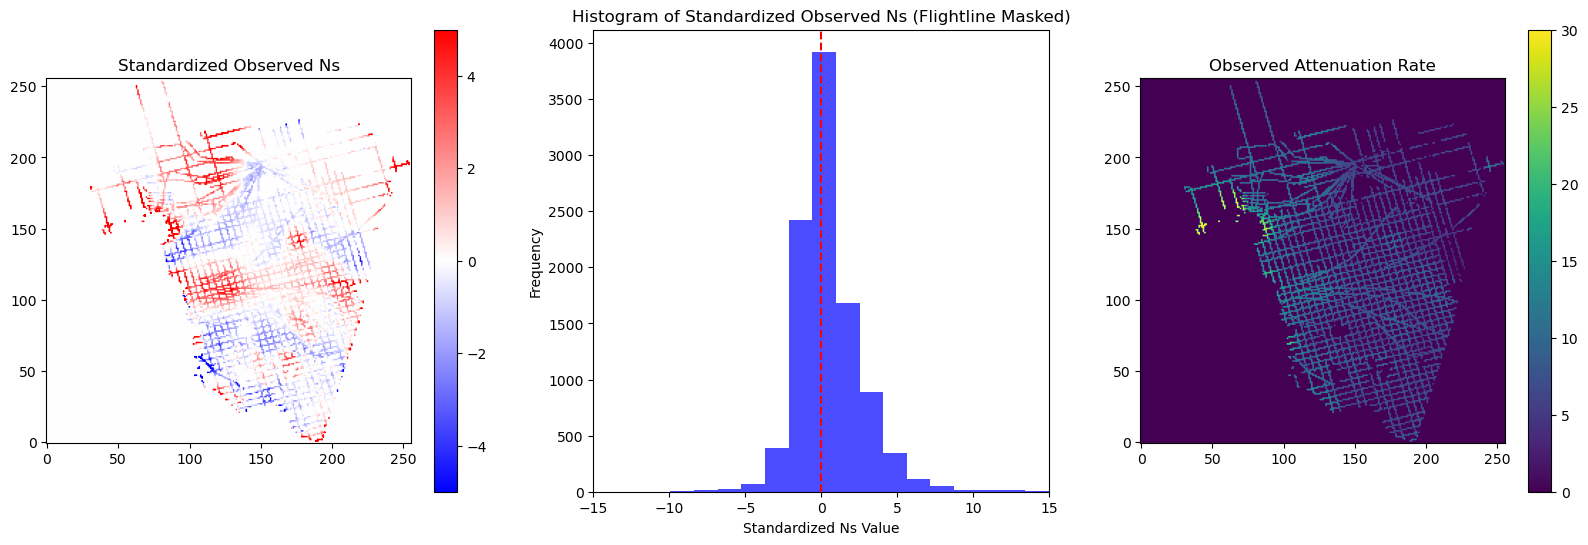

In [4]:
md.load_obs_data(atten_rate_avg)

Density at init: [0.00032939]
 Likelihood: 9.695, Prior: 8.018
 Likelihood: 9.737, Prior: 8.867
 Likelihood: 9.348, Prior: 8.106
 Likelihood: 9.332, Prior: 8.111
 Likelihood: 9.318, Prior: 8.116
 Likelihood: 9.291, Prior: 8.136
 Likelihood: 9.292, Prior: 8.135
 Likelihood: 9.292, Prior: 8.135
 Likelihood: 9.292, Prior: 8.135
 Likelihood: 9.292, Prior: 8.135
 Likelihood: 9.292, Prior: 8.135
Optimization success: True
CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
Iterations: 9
Function evaluations: 11
Final objective: 17.4264
Density at init: [0.00032939]
 Likelihood: 4.500, Prior: 8.018
 Likelihood: 4.318, Prior: 8.201
 Likelihood: 4.368, Prior: 8.064
 Likelihood: 4.361, Prior: 8.069
 Likelihood: 4.363, Prior: 8.065
 Likelihood: 4.361, Prior: 8.065
 Likelihood: 4.358, Prior: 8.068
 Likelihood: 4.357, Prior: 8.069
 Likelihood: 4.357, Prior: 8.069
 Likelihood: 4.357, Prior: 8.069
 Likelihood: 4.357, Prior: 8.069
Optimization success: True
CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTO

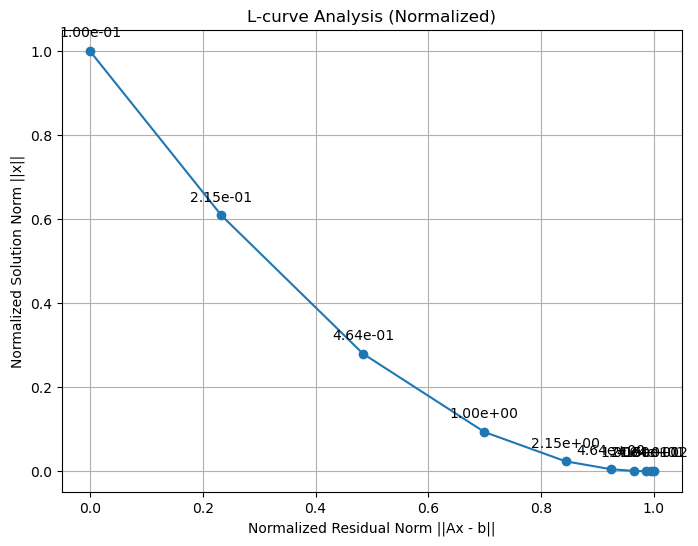

Density at init: [0.00032939]
 Likelihood: 0.970, Prior: 8.018
 Likelihood: 0.955, Prior: 8.027
 Likelihood: 0.957, Prior: 8.025
 Likelihood: 0.956, Prior: 8.026
 Likelihood: 0.957, Prior: 8.024
 Likelihood: 0.957, Prior: 8.024
 Likelihood: 0.957, Prior: 8.024
 Likelihood: 0.957, Prior: 8.024
 Likelihood: 0.957, Prior: 8.024
Optimization success: True
CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
Iterations: 7
Function evaluations: 9
Final objective: 8.9810


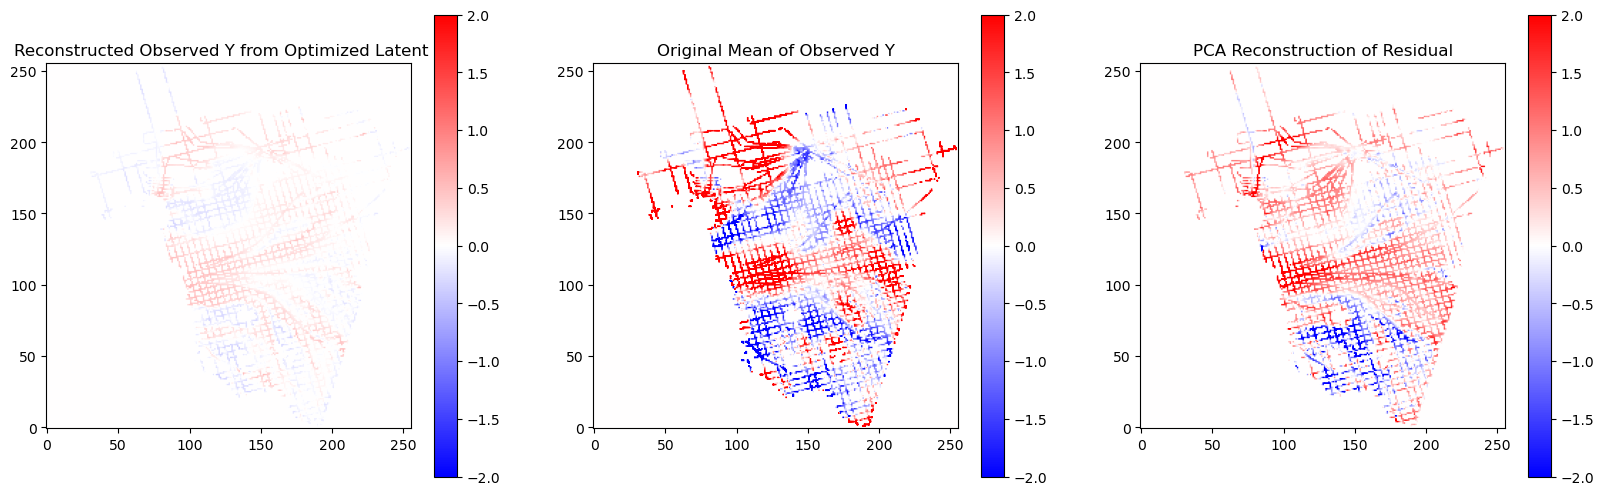

first 5x5 block of cov_obs_latent:
[[8611.04910105  719.22648796 -989.03020521  737.5689823 ]
 [ 719.22648796  930.88472359 -441.31045145  329.10713832]
 [-989.03020521 -441.31045145  888.72146612 -452.56522946]
 [ 737.5689823   329.10713832 -452.56522946  421.7298902 ]]
min eigenvalue: 19.79421001322308
conditioned indices are:  [0 1 2 3 4 5 6 7]


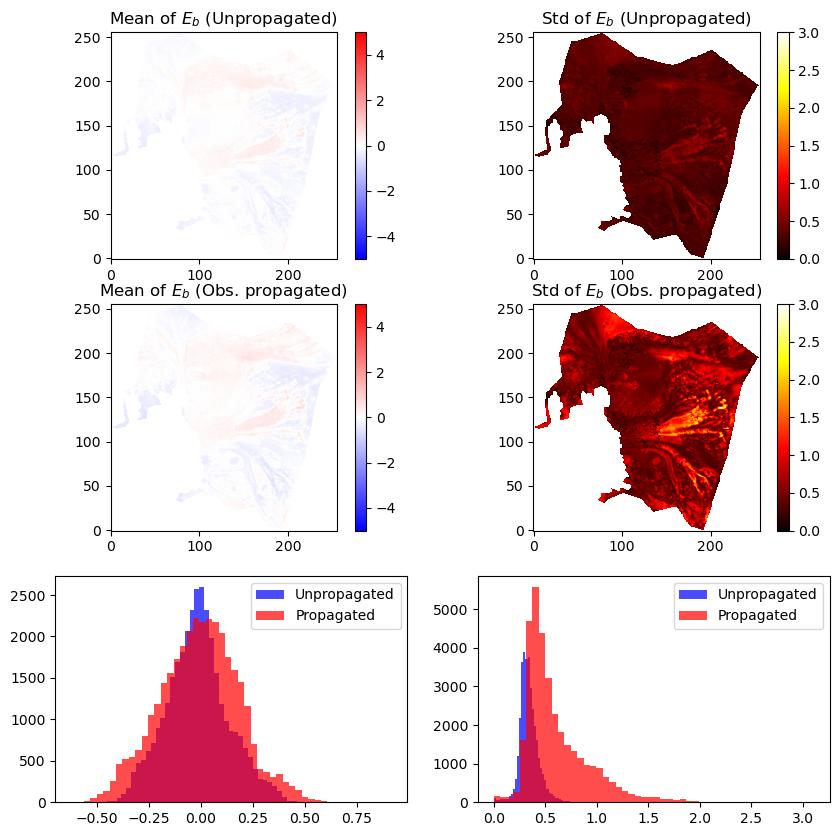

In [5]:
from src.validation import lcurve_analysis
def opt_func(beta):
    return md.compute_optimal_Y_in_latent(beta=beta, show_plot=False)

beta_prior_list = np.logspace(-1, 2, 10)
lcurve_analysis(opt_func=opt_func, beta_prior_list=beta_prior_list)

# the beta_prior comes from the L-curve plot
beta_prior = 1
lambda1, lambda2 = 1,1
md.derive_prior(beta=beta_prior, lambda1=lambda1, lambda2=lambda2)

## Part (iv): loading basal thermal evidence

In [6]:
from src.ice import compute_pmp

# load the thawed base and frozen base data
frozen_base_filename = folder + "../../basal-frozen-mask/frozen_mask.mat"
thawed_base_filename = folder + "../../basal-water-mask/water_mask.mat"
frozen_mask = scipy.io.loadmat(frozen_base_filename)['frozen_mask']
thawed_mask = scipy.io.loadmat(thawed_base_filename)['water_mask']
frozen_mask_data = frozen_mask['data'][0][0]
thawed_mask_data = thawed_mask['data'][0][0]

Eb_mean_data = scipy.io.loadmat(folder + Eb_mean_filename)
Eb_std_data = scipy.io.loadmat(folder + Eb_std_filename)
# replace nan by 0
Eb_mean_data = np.nan_to_num(Eb_mean_data['Eb_mean'], nan=0.0)
Eb_std_data = np.nan_to_num(Eb_std_data['Eb_std'], nan=0.0)

# compute pmp
H = H_data['H_struct']['H'][0][0].flatten()
X = H_data['H_struct']['X'][0][0].flatten()
Y = H_data['H_struct']['Y'][0][0].flatten()
pmp = compute_pmp(H)

# into a vector
Eb_mean_data = Eb_mean_data.flatten()
Eb_std_data = Eb_std_data.flatten()
frozen_mask_data = frozen_mask_data.flatten()
thawed_mask_data = thawed_mask_data.flatten()

# set fractional area to 1 for all locations (assumption for now, can be relaxed later)
thawed_fractional_area = np.zeros_like(thawed_mask_data)
frozen_fractional_area = np.zeros_like(frozen_mask_data)
thawed_fractional_area[thawed_mask_data == 1] = 1.0
frozen_fractional_area[frozen_mask_data == 1] = 1.0

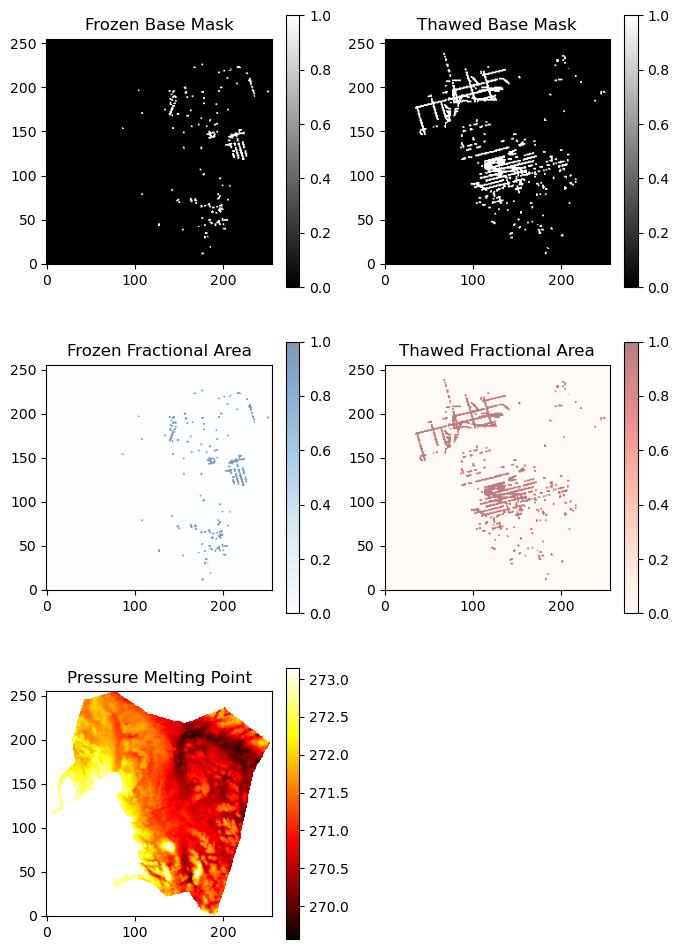

In [7]:
md.load_evidence(thawed_mask_data, thawed_fractional_area,
                 frozen_mask_data, frozen_fractional_area,
                 pmp,
                 show_plot=True)

#### Prior predictive check...

Number of frozen grid points: 900
Number of thawed grid points: 3693
Sample 0/2000
Sample 500/2000
Sample 1000/2000
Sample 1500/2000


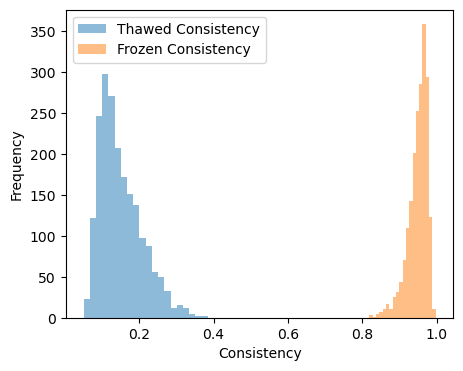

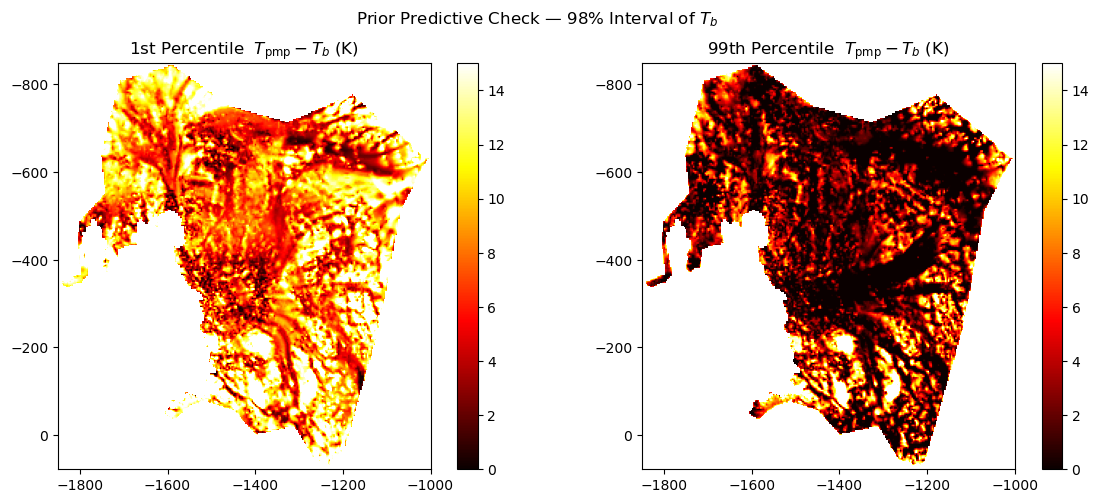

In [8]:
from src.utilities import reverse_standardize
from src.ice import enthalpy_to_temperature
# sample from prior and compute the likelihood
n_prior_samples = 2000
prior_samples = md.gmm_prop.sample(n_prior_samples)

n_frozen = np.sum(md.frozen_mask)
n_thawed = np.sum(md.thawed_mask)
print("Number of frozen grid points:", n_frozen)
print("Number of thawed grid points:", n_thawed)

thawed_consistent = np.zeros(n_prior_samples,)
frozen_consistent = np.zeros(n_prior_samples,)
Tb_prior_samples = np.zeros((n_prior_samples, md.domain_mask.sum()))  
for i, sample in enumerate(prior_samples):
    Eb_sample = md.pca_x.inverse_transform(sample)
    Eb_sample_ori = reverse_standardize(Eb_sample,
                                        md.X_mean, 
                                        md.X_std, 
                                        method='relaxation',
                                        epsilon=md.X_epsilon)
    Tb_sample_ori = enthalpy_to_temperature(Eb_sample_ori, md.pmp, istorch=False)
    Tb_prior_samples[i] = Tb_sample_ori[md.domain_mask.flatten()]

    thawed = (Tb_sample_ori - md.pmp) >= -1
    frozen = (md.pmp - Tb_sample_ori) >= 1

    thawed[md.domain_mask.flatten() == False] = np.nan
    frozen[md.domain_mask.flatten() == False] = np.nan

    frozen_consistent[i] = np.nansum(frozen[md.frozen_mask==True])
    thawed_consistent[i] = np.nansum(thawed[md.thawed_mask==True])

    if i % 500 == 0:
        print("Sample {}/{}".format(i, n_prior_samples))

plt.figure(figsize=(5,4))
plt.hist(thawed_consistent/n_thawed, bins=20, alpha=0.5, label='Thawed Consistency')
plt.hist(frozen_consistent/n_frozen, bins=20, alpha=0.5, label='Frozen Consistency')
plt.xlabel('Consistency')
plt.ylabel('Frequency')
plt.legend()
plt.show()


# Compute percentiles across samples (axis=0 → per pixel)
Tb_plow = np.nanpercentile(Tb_prior_samples, 1,  axis=0)
Tb_phigh = np.nanpercentile(Tb_prior_samples, 99, axis=0)

# Reconstruct spatial maps
domain_idx = np.where(md.domain_mask.flatten())[0]
Tb_plow_map = np.full(md.domain_mask.flatten().shape, np.nan)
Tb_phigh_map = np.full(md.domain_mask.flatten().shape, np.nan)
Tb_plow_map[domain_idx] = Tb_plow
Tb_phigh_map[domain_idx] = Tb_phigh

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].imshow(md.pmp.reshape(md.ny, md.nx) - Tb_plow_map.reshape(md.ny, md.nx),
                      extent=md.extent, origin='lower', cmap='hot',
                      vmin=0, vmax=15)
axes[0].set_title("1st Percentile  $T_\\mathrm{pmp} - T_b$ (K)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(md.pmp.reshape(md.ny, md.nx) - Tb_phigh_map.reshape(md.ny, md.nx),
                      extent=md.extent, origin='lower', cmap='hot',
                      vmin=0, vmax=15)
axes[1].set_title("99th Percentile  $T_\\mathrm{pmp} - T_b$ (K)")
plt.colorbar(im1, ax=axes[1])

plt.suptitle("Prior Predictive Check — 98% Interval of $T_b$")
plt.tight_layout()
plt.show()

## Part (v): Computing MAP and posterior distribution

First we need to find a proper $\beta$ in the likelihood function. We use K-fold cross validation to find beta around the inflection point

In [8]:
from src.validation import split_evidence
from src.optimization import loglikelihoods_sum
import torch
import contextlib
import copy
beta_posterior_list = [0.5, 1, 2, 3, 4, 5]
mask_idx = np.where(md.combined_mask)[0]
subsets_mask_idx = split_evidence(mask_idx, 10)

orig_thawed_mask      = md.thawed_mask.copy()
orig_frozen_mask      = md.frozen_mask.copy()
orig_thawed_frac_area = md.thawed_fractional_area.copy()
orig_frozen_frac_area = md.frozen_fractional_area.copy()
orig_pmp              = md.pmp  # or .copy() if it's an array

Tb_MAP_betas = []
ll_betas = []
# suppress output 
for beta_posterior in beta_posterior_list:
    md_copy = copy.deepcopy(md)  # deepcopy, not copy.copy
    
    Tb_MAP_subsets = []
    ll_subsets = []

    for ii, mask in enumerate(subsets_mask_idx):
        # ── Training set: all evidence EXCEPT this fold ──────────────
        train_idx = np.concatenate([subsets_mask_idx[j] 
                                    for j in range(len(subsets_mask_idx)) if j != ii])

        train_evidence  = np.zeros_like(md.combined_mask, dtype=bool)
        train_evidence[train_idx] = True

        train_thawed_mask     = np.logical_and(orig_thawed_mask, train_evidence)
        train_frozen_mask     = np.logical_and(orig_frozen_mask, train_evidence)
        train_thawed_frac     = np.zeros_like(orig_thawed_frac_area)
        train_frozen_frac     = np.zeros_like(orig_frozen_frac_area)
        train_thawed_frac[train_thawed_mask] = 1.0
        train_frozen_frac[train_frozen_mask] = 1.0

        # ── Test set: this fold only ──────────────────────────────────
        test_evidence = np.zeros_like(md.combined_mask, dtype=bool)
        test_evidence[mask] = True

        test_thawed_frac = np.zeros_like(orig_thawed_frac_area)
        test_frozen_frac = np.zeros_like(orig_frozen_frac_area)
        test_thawed_frac[np.logical_and(orig_thawed_mask, test_evidence)] = 1.0
        test_frozen_frac[np.logical_and(orig_frozen_mask, test_evidence)] = 1.0

        # ── Fit on training set ───────────────────────────────────────
        with open(os.devnull, 'w') as f, contextlib.redirect_stdout(f):
            md_copy.load_evidence(train_thawed_mask, train_thawed_frac,
                                  train_frozen_mask, train_frozen_frac,
                                  orig_pmp, show_plot=False)
            md_copy.compute_MAP(beta=beta_posterior, n_iter=20, lr=0.5, show_plot=False)

        # ── Evaluate on held-out test fold ────────────────────────────
        Tb_MAP_subsets.append(md_copy.Tb_MAP.copy())
        Tb_flat = md_copy.Tb_MAP.copy().flatten()
        Tb_flat[np.isnan(Tb_flat)] = 0.0

        with torch.no_grad():
            ll = loglikelihoods_sum(beta_posterior,
                                    torch.from_numpy(Tb_flat),
                                    torch.from_numpy(md_copy.pmp),
                                    torch.from_numpy(test_thawed_frac), 
                                    torch.from_numpy(test_frozen_frac)) 
        ll_subsets.append(ll)

    Tb_MAP_subsets_array = np.array(Tb_MAP_subsets)
    Tb_MAP_betas.append(Tb_MAP_subsets_array)
    ll_subsets_array = np.array(ll_subsets)
    ll_betas.append(ll_subsets_array)

    print(f"Completed beta_posterior = {beta_posterior}")
    print(f"The log-likelihoods for the subsets are: {ll_subsets_array}")


/home/donglaiyang/Documents/Georgia-Tech/Research/GMR-inference/notebooks/../src/optimization.py:253: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Eb_star_tensor = torch.tensor(Eb_star, requires_grad=True)


KeyboardInterrupt: 

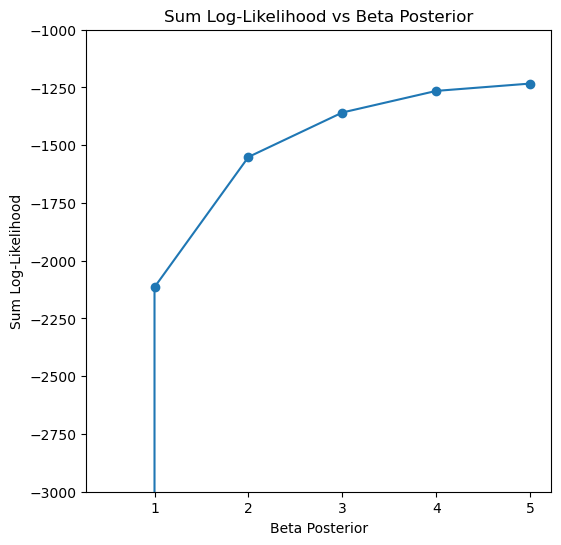

In [18]:
sum_llm = np.sum(ll_betas, axis=1)
plt.figure(figsize=(6,6))
plt.plot(beta_posterior_list, sum_llm, marker='o')
plt.ylim(-3000, -1000)
plt.xlabel('Beta Posterior')
plt.ylabel('Sum Log-Likelihood')
plt.title('Sum Log-Likelihood vs Beta Posterior')
plt.show()

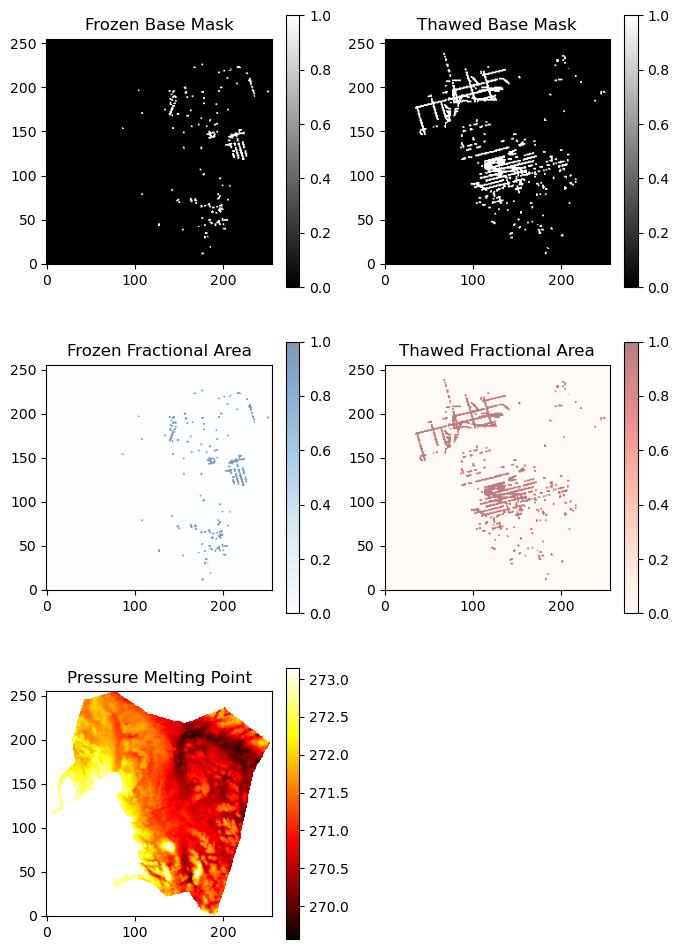

Starting iteration 1/20...
Iteration 1/20, Negative Log Posterior: 1935.1789
Starting iteration 2/20...
Iteration 2/20, Negative Log Posterior: 1894.3387
Starting iteration 3/20...
Iteration 3/20, Negative Log Posterior: 1888.5057
Starting iteration 4/20...
Iteration 4/20, Negative Log Posterior: 1888.4961
Starting iteration 5/20...
Iteration 5/20, Negative Log Posterior: 1888.4957
Starting iteration 6/20...
Iteration 6/20, Negative Log Posterior: 1888.4958
Starting iteration 7/20...
Iteration 7/20, Negative Log Posterior: 1888.4967
Starting iteration 8/20...
Iteration 8/20, Negative Log Posterior: 1888.4961
Starting iteration 9/20...
Iteration 9/20, Negative Log Posterior: 1888.4980
Starting iteration 10/20...
Iteration 10/20, Negative Log Posterior: 1888.4957
Starting iteration 11/20...
Iteration 11/20, Negative Log Posterior: 1888.4957
Starting iteration 12/20...
Iteration 12/20, Negative Log Posterior: 1888.4961
Starting iteration 13/20...
Iteration 13/20, Negative Log Posterior: 1

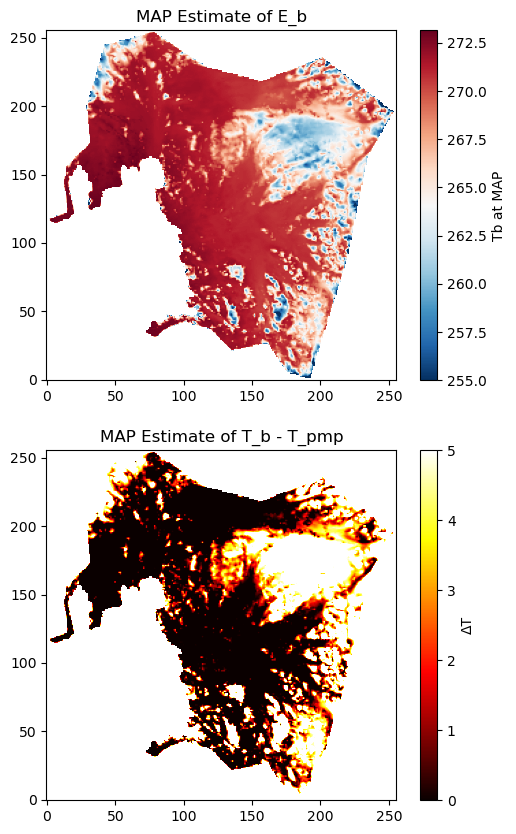

In [9]:
md.load_evidence(thawed_mask_data, thawed_fractional_area,
                 frozen_mask_data, frozen_fractional_area,
                 pmp,
                 show_plot=True)

beta_posterior = 2 # taking the elbow point from the k-fold cross-validation analysis above
md.compute_MAP(beta=beta_posterior, n_iter=20, lr=0.5)

Total consistent points: 4104 out of 4593 (89.35%)


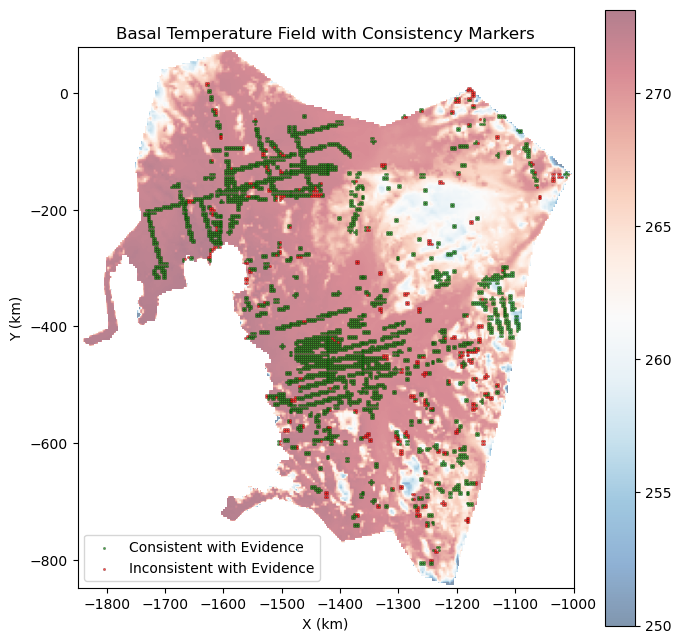

In [10]:
md.plot_evidence_consistency(md.Tb_MAP.flatten(), beta=beta_posterior)

In [21]:
md.explore_posterior(beta=beta_posterior)


EXPLORE: Exploratory run to discover modes
         warmup=2000, samples=500


Warmup:   0%|          | 0/2500 [00:00, ?it/s]/home/donglaiyang/Documents/Georgia-Tech/Research/GMR-inference/notebooks/../src/optimization.py:253: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Eb_star_tensor = torch.tensor(Eb_star, requires_grad=True)
Sample: 100%|██████████| 2500/2500 [43:07,  1.04s/it, step size=4.24e-02, acc. prob=0.819]

Exploratory samples collected: torch.Size([500, 25])

Detected 1 mode(s) in PCA Component 0:
  Mode 1: Component 0 ≈ 368.565
  Init z[0] = 368.568  (target 368.565)
Diagnostic plot saved.

explore_posterior() complete. Call derive_posterior() to run full sampling.


In [30]:
md.derive_posterior(warmup_steps=1000, num_samples=3000)


DERIVE: Full sampling from 1 mode(s)
        warmup=1000, samples=3000 per mode

--- Mode 1 / 1 (Component 0 ≈ 368.565) ---
  Log prob at initialization: -1890.1961


Warmup:   0%|          | 0/4000 [00:00, ?it/s]/home/donglaiyang/Documents/Georgia-Tech/Research/GMR-inference/notebooks/../src/optimization.py:253: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Eb_star_tensor = torch.tensor(Eb_star, requires_grad=True)
Sample: 100%|██████████| 4000/4000 [52:55,  1.26it/s, step size=6.49e-02, acc. prob=0.727]

  Collected 3000 samples.

Mode weights (softmax of log probs at mode centers):
  Mode 1: 1.0000
  Mode 1: using 3000 / 3000 samples

Total combined samples: 3000

All results saved to mcmc_run_beta_2.pt


In [11]:
md.analyze_posterior_samples(beta=beta_posterior, loading=True)

/home/donglaiyang/Documents/Georgia-Tech/Research/GMR-inference/notebooks/../src/model.py:1053: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mcmc_dict = torch.load(f"../dat

HMC Sampling Complete. Extracted shape: (3000, 25)


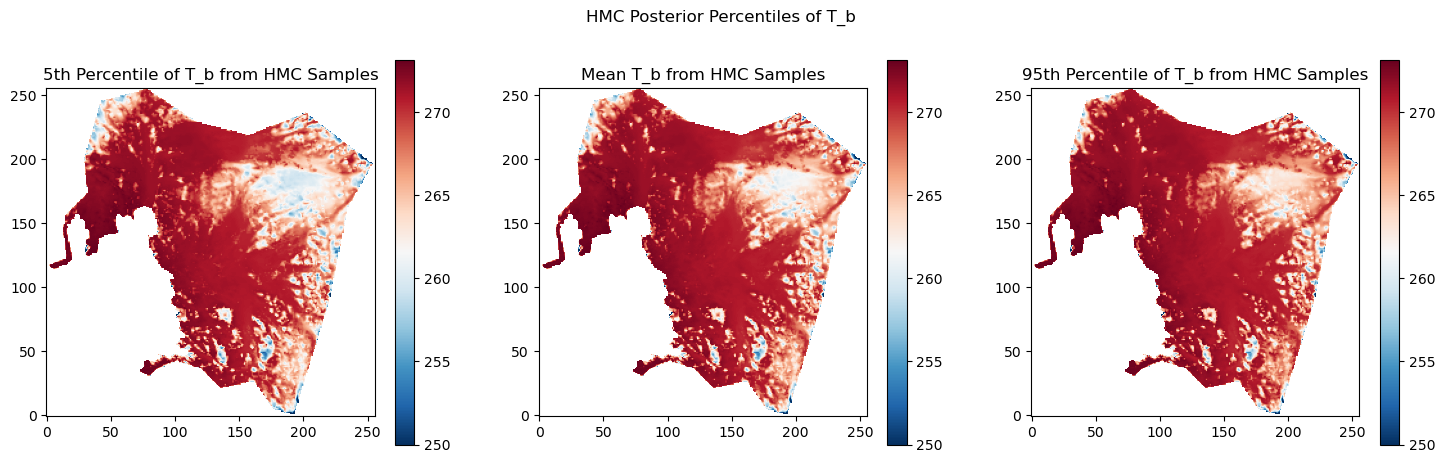

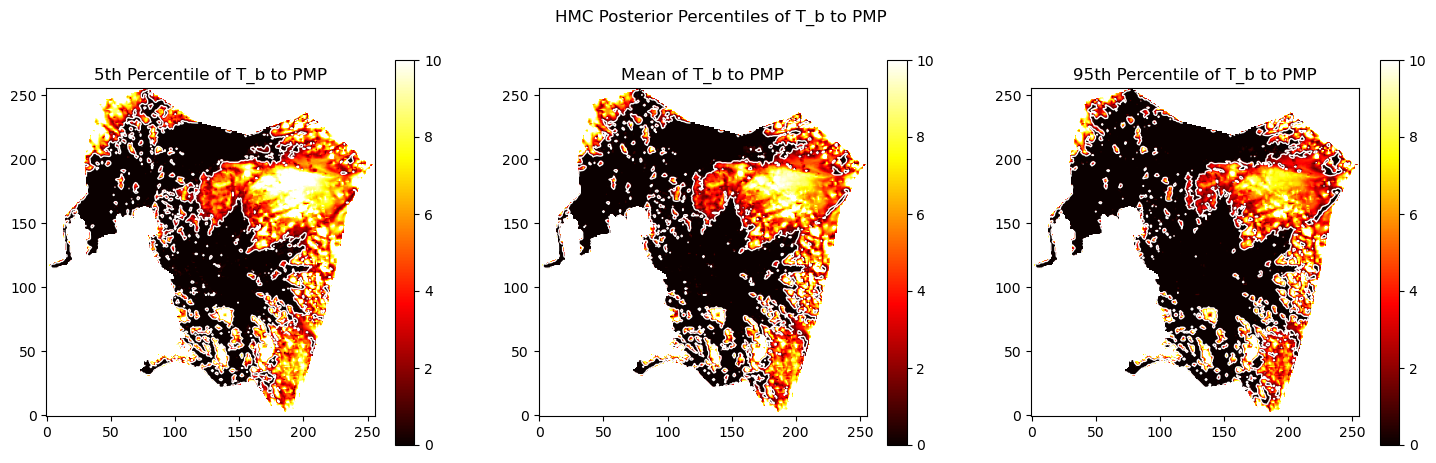

In [12]:
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.imshow(md.Tb_p5, cmap='RdBu_r', vmin=250, vmax=273.15)
plt.title('5th Percentile of T_b from HMC Samples')
plt.colorbar()
plt.gca().invert_yaxis()
plt.subplot(1, 3, 2)
plt.imshow(md.Tb_mean, cmap='RdBu_r', vmin=250, vmax=273.15)
plt.title('Mean T_b from HMC Samples')
plt.colorbar()
plt.gca().invert_yaxis()
plt.subplot(1, 3, 3)
plt.imshow(md.Tb_p95, cmap='RdBu_r', vmin=250, vmax=273.15)
plt.title('95th Percentile of T_b from HMC Samples')
plt.colorbar()
plt.gca().invert_yaxis()
plt.suptitle('HMC Posterior Percentiles of T_b')
plt.show()

deg2pmp_p5 = (md.pmp - md.Tb_p5.flatten()).reshape(md.nx, md.ny)
deg2pmp_mean = (md.pmp - md.Tb_mean.flatten()).reshape(md.nx, md.ny)
deg2pmp_p95 = (md.pmp - md.Tb_p95.flatten()).reshape(md.nx, md.ny)
deg2pmp_p5[md.domain_mask == False] = np.nan
deg2pmp_mean[md.domain_mask == False] = np.nan
deg2pmp_p95[md.domain_mask == False] = np.nan
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.imshow(deg2pmp_p5, cmap='hot', vmin=0, vmax=10)
plt.colorbar()  
# add contourline of 1
plt.contour(deg2pmp_p5, levels=[1], colors='white', linewidths=1)
plt.title('5th Percentile of T_b to PMP')
plt.gca().invert_yaxis()

plt.subplot(1, 3, 2)
plt.imshow(deg2pmp_mean , cmap='hot', vmin=0, vmax=10)
plt.colorbar()
# add contourline of 1
plt.contour(deg2pmp_mean, levels=[1], colors='white', linewidths=1)
plt.gca().invert_yaxis()
plt.title('Mean of T_b to PMP')

plt.subplot(1, 3, 3)
plt.imshow(deg2pmp_p95 , cmap='hot', vmin=0, vmax=10)
plt.colorbar()
# add contourline of 1
plt.contour(deg2pmp_p95, levels=[1], colors='white', linewidths=1)
plt.title('95th Percentile of T_b to PMP')
plt.gca().invert_yaxis()
plt.suptitle('HMC Posterior Percentiles of T_b to PMP')
plt.show()

--- HMC Sampling Metrics ---
Total Samples Drawn: 3000
Mean ESS across all dimensions: 745.60
Minimum ESS (Worst mixing dimension): 318.74
Maximum ESS (Best mixing dimension): 1413.83
Post-Burn-in Mean ESS: 745.60
Post-Burn-in Min ESS: 318.74


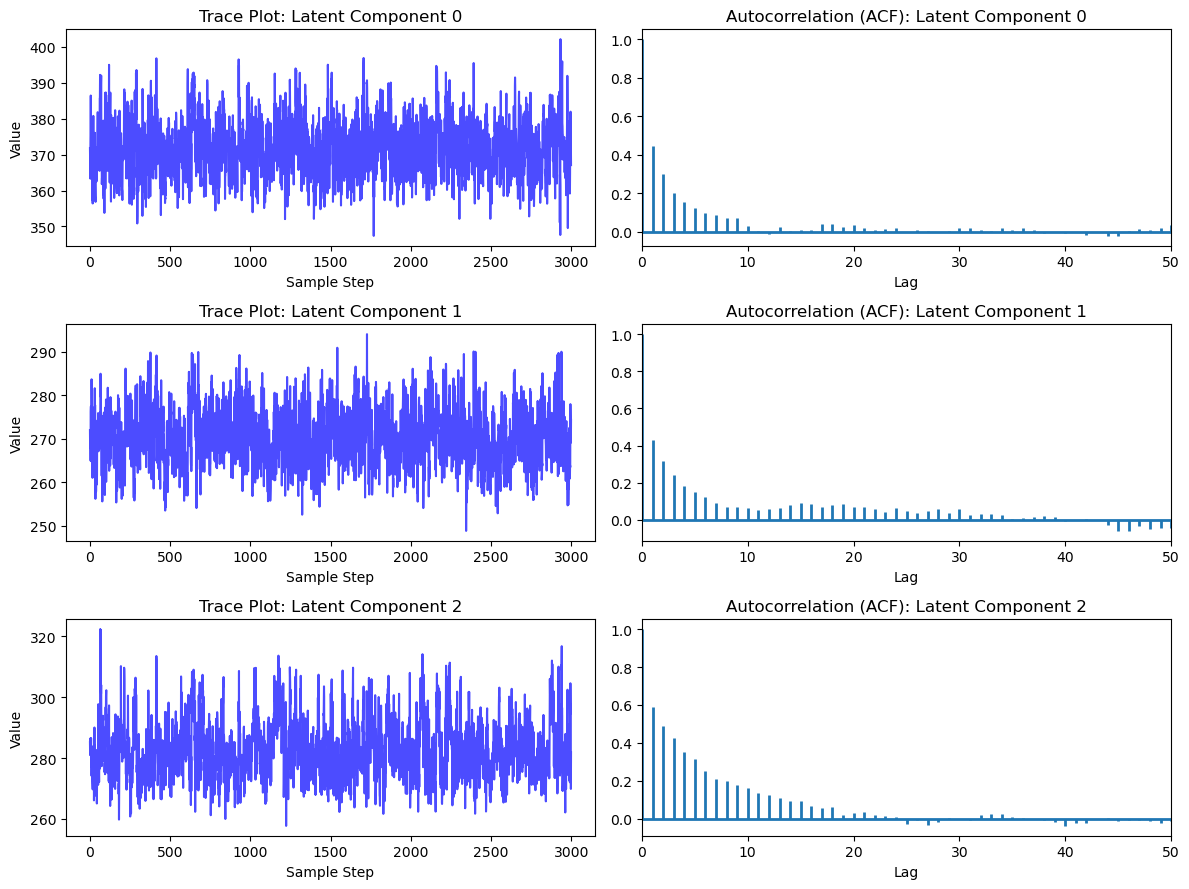

In [14]:
md.posterior_quality_check(slicing=0)